In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# **Чтение данных из датасета (набора курсов)**

In [ ]:
df = pd.read_csv("courses_rows.csv")
df_embeddings = df['embedding'].apply(lambda s: np.array(list(map(float,s[1:-1].split(","))),dtype=np.float64))
embedding_matrix = np.vstack(df_embeddings)
df_embeddings = pd.DataFrame(embedding_matrix, columns=["e" + str(i) for i in range(len(embedding_matrix[0]))])
df = pd.concat([df, df_embeddings], axis=1)
df.drop(columns=["summary", "title", "id", "stepik_id", "tags", "url", "embedding", "created_at", "updated_at", "rating"], inplace=True)
df.fillna({"price": 0}, inplace=True)
df["is_paid"] = df["is_paid"].apply(lambda x: int(x))
df.dropna(inplace=True)
df["difficulty"] = df["difficulty"].apply(lambda x: ["easy", "normal", "hard"].index(x) + 1)

# **Отбор эмбеддингов**

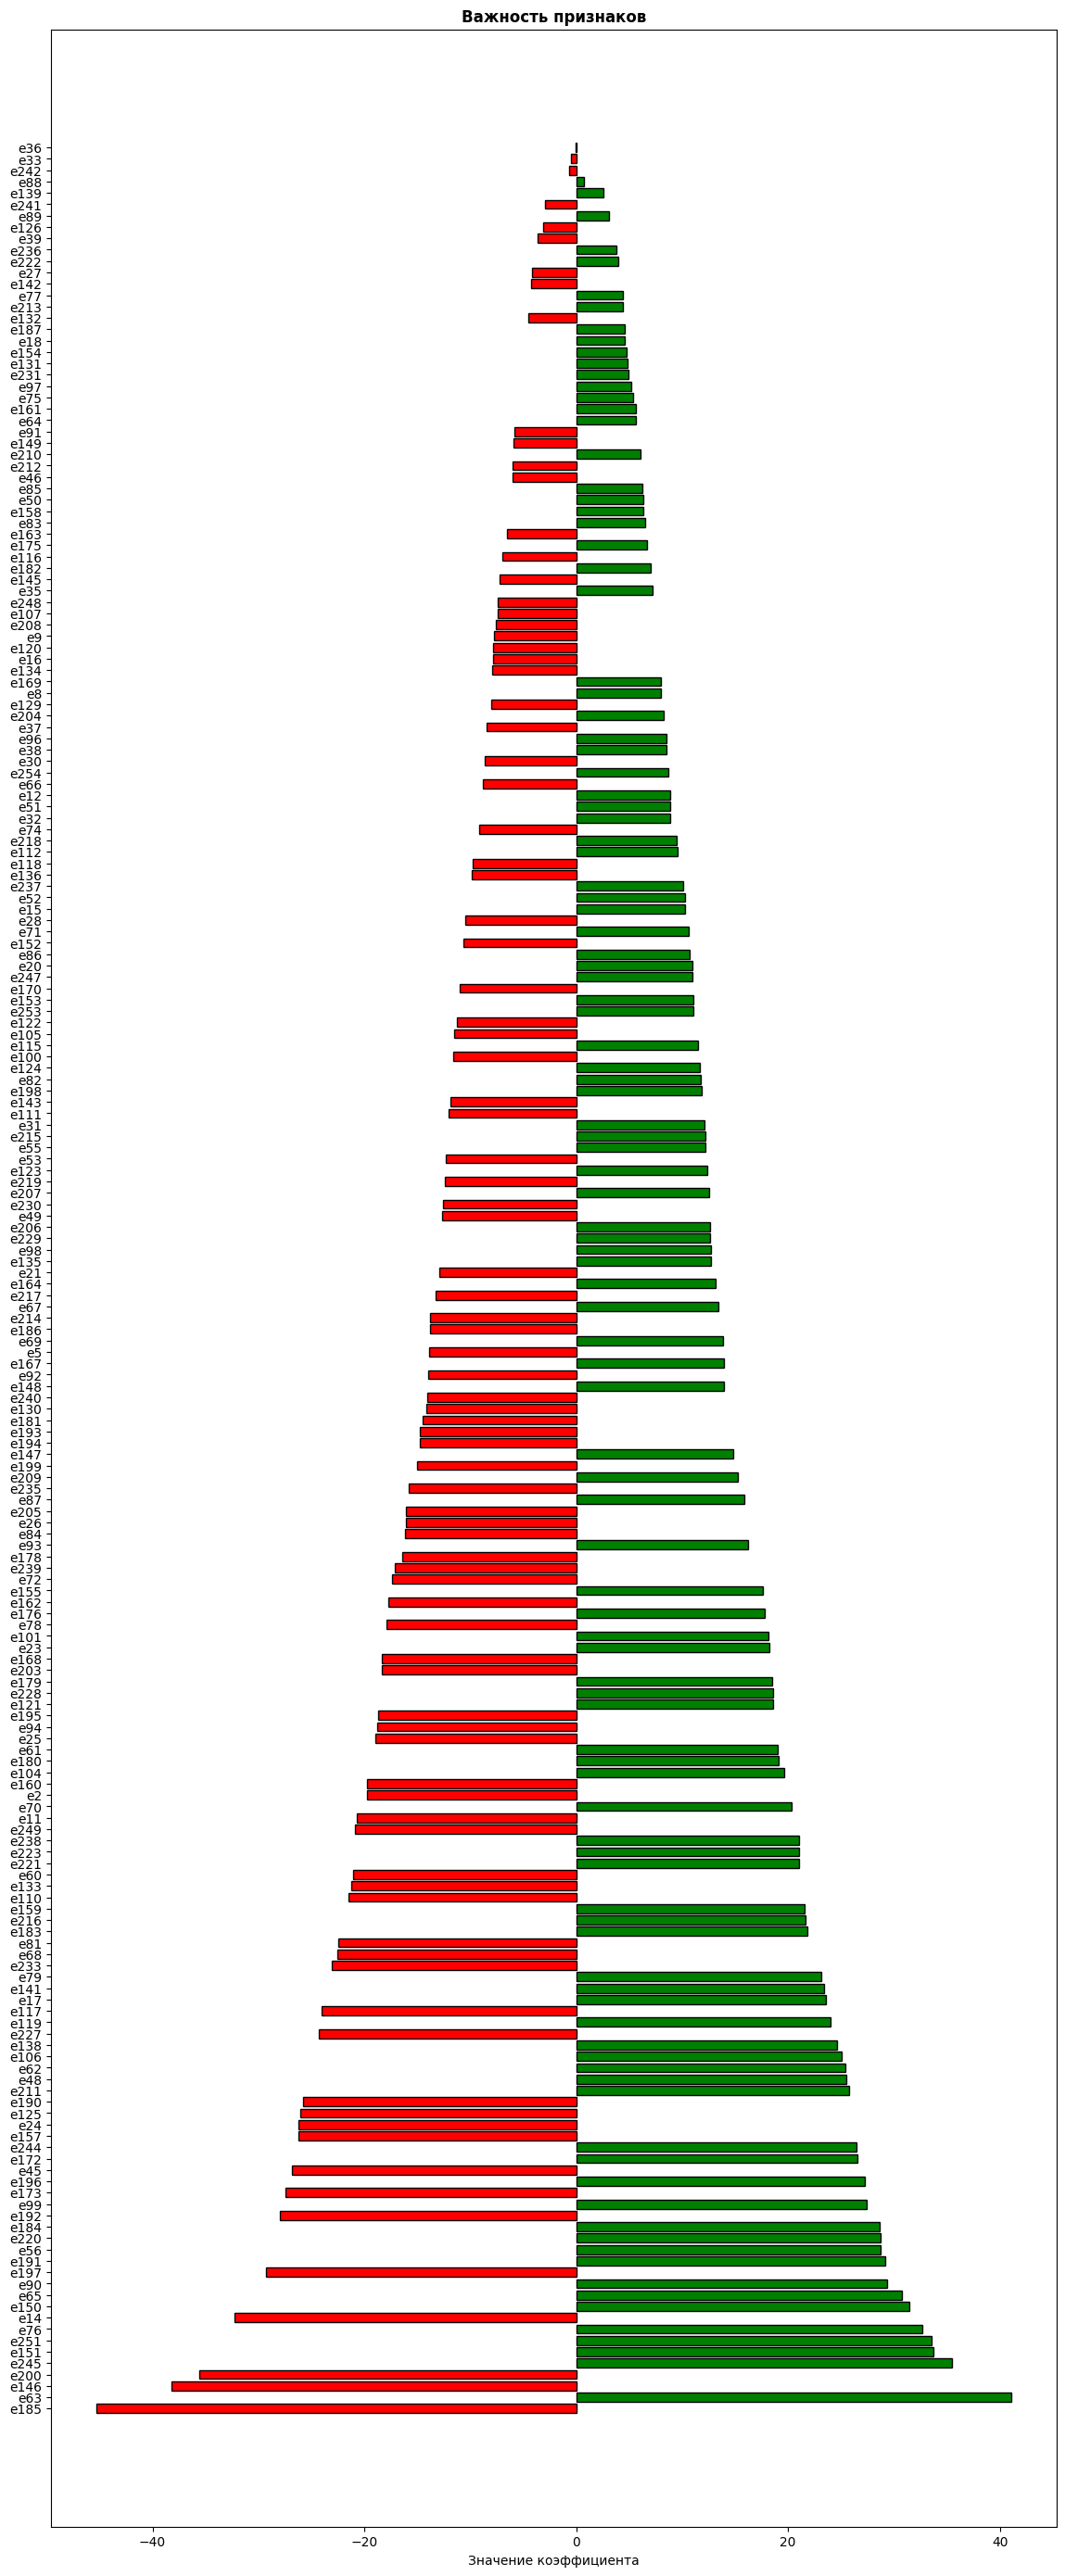

In [ ]:
from sklearn.linear_model import LinearRegression

X = df.drop(columns=["difficulty"])
y = df["difficulty"]

lr = LinearRegression()

lr.fit(X,y)

fig, axes = plt.subplots(1, 1, figsize=(14, 35))
coefficients = pd.DataFrame({
    'feature': X.columns,
    'coef': lr.coef_
})
coefficients = coefficients.sort_values(by='coef', key=lambda x: np.abs(x), ascending=False)

colors = ['green' if c > 0 else 'red' for c in coefficients['coef']]
bars = plt.barh(coefficients['feature'], coefficients['coef'], color=colors, edgecolor='black')
plt.xlabel('Значение коэффициента', fontsize=10)
plt.title('Важность признаков', fontsize=12, fontweight='bold')
plt.show()

In [ ]:
def thresholder(vals, t1 = 1.5, t2 = 2):
  for val in range(len(vals)):
    if vals[val] > t2:
      vals[val] = 3
    elif vals[val] > t1:
      vals[val] = 2
    else:
      vals[val] = 1
  return vals

In [ ]:
y_pred = thresholder(lr.predict(X))
pd.Series(y_pred).value_counts()

,count
1.0,1301
2.0,381
3.0,25


In [ ]:
from sklearn.metrics import accuracy_score, f1_score


print(accuracy_score(y, y_pred), f1_score(y, y_pred, average="macro"))

0.8646748681898067 0.6108527002654609


In [ ]:
df.drop(columns=[f for f in coefficients["feature"].iloc[200:]],inplace=True)

# **Обучение и сохранение модели**

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["difficulty"])
y = df["difficulty"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators=50)

rfr.fit(X_train, y_train)

y_pred_train = thresholder(rfr.predict(X_train))
y_pred_test = thresholder(rfr.predict(X_test))

print("f1 train:", f1_score(y_train, y_pred_train, average="micro"), "f1 test:", f1_score(y_test, y_pred_test, average="micro"))

f1 train: 1.0 f1 test: 0.7485380116959064


In [ ]:
import pickle
sav = open("difficulty_prediction","wb")
pickle.dump(rfr,sav)
sav.close()